In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
df = pd.read_csv('../data/housing_clean.csv')
pd.options.display.float_format = '{:.2f}'.format
df.head(10)


,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,sale_year,sale_month
0,7129300520,221900.00,3,1.00,1180,5650,1.00,0,0,3,...,0,1955,0,98178,47.51,-122.26,1340,5650,2014,10
1,6414100192,538000.00,3,2.25,2570,7242,2.00,0,0,3,...,400,1951,1991,98125,47.72,-122.32,1690,7639,2014,12
2,5631500400,180000.00,2,1.00,770,10000,1.00,0,0,3,...,0,1933,0,98028,47.74,-122.23,2720,8062,2015,2
3,2487200875,604000.00,4,3.00,1960,5000,1.00,0,0,5,...,910,1965,0,98136,47.52,-122.39,1360,5000,2014,12
4,1954400510,510000.00,3,2.00,1680,8080,1.00,0,0,3,...,0,1987,0,98074,47.62,-122.05,1800,7503,2015,2
5,7237550310,1225000.00,4,4.50,5420,101930,1.00,0,0,3,...,1530,2001,0,98053,47.66,-122.00,4760,101930,2014,5
6,1321400060,257500.00,3,2.25,1715,6819,2.00,0,0,3,...,0,1995,0,98003,47.31,-122.33,2238,6819,2014,6
7,2008000270,291850.00,3,1.50,1060,9711,1.00,0,0,3,...,0,1963,0,98198,47.41,-122.31,1650,9711,2015,1
8,2414600126,229500.00,3,1.00,1780,7470,1.00,0,0,3,...,730,1960,0,98146,47.51,-122.34,1780,8113,2015,4
9,3793500160,323000.00,3,2.50,1890,6560,2.00,0,0,3,...,0,2003,0,98038,47.37,-122.03,2390,7570,2015,3


In [857]:
X = df.drop('price', axis =1)
y = df['price']

In [858]:
X.head(10)

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,sale_year,sale_month
0,7129300520,3,1.00,1180,5650,1.00,0,0,3,7,...,0,1955,0,98178,47.51,-122.26,1340,5650,2014,10
1,6414100192,3,2.25,2570,7242,2.00,0,0,3,7,...,400,1951,1991,98125,47.72,-122.32,1690,7639,2014,12
2,5631500400,2,1.00,770,10000,1.00,0,0,3,6,...,0,1933,0,98028,47.74,-122.23,2720,8062,2015,2
3,2487200875,4,3.00,1960,5000,1.00,0,0,5,7,...,910,1965,0,98136,47.52,-122.39,1360,5000,2014,12
4,1954400510,3,2.00,1680,8080,1.00,0,0,3,8,...,0,1987,0,98074,47.62,-122.05,1800,7503,2015,2
5,7237550310,4,4.50,5420,101930,1.00,0,0,3,11,...,1530,2001,0,98053,47.66,-122.00,4760,101930,2014,5
6,1321400060,3,2.25,1715,6819,2.00,0,0,3,7,...,0,1995,0,98003,47.31,-122.33,2238,6819,2014,6
7,2008000270,3,1.50,1060,9711,1.00,0,0,3,7,...,0,1963,0,98198,47.41,-122.31,1650,9711,2015,1
8,2414600126,3,1.00,1780,7470,1.00,0,0,3,7,...,730,1960,0,98146,47.51,-122.34,1780,8113,2015,4
9,3793500160,3,2.50,1890,6560,2.00,0,0,3,7,...,0,2003,0,98038,47.37,-122.03,2390,7570,2015,3


In [859]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

X_train_0, X_test_0, y_train_0, y_test_0 = X_train.copy(), X_test.copy(), y_train.copy(), y_test.copy()

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (17289, 21)
X_test shape: (4323, 21)


# function to store the scores

In [860]:
def evaluate_model(model_name, y_train, y_pred_train, y_test, y_pred):
    return pd.DataFrame([{
        "Model": model_name,
        "Train_RMSE": np.sqrt(mean_squared_error(y_train, y_pred_train)),
        "Test_RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "Train_MAE": mean_absolute_error(y_train, y_pred_train),
        "Test_MAE": mean_absolute_error(y_test, y_pred),
        "Train_R2": r2_score(y_train, y_pred_train),
        "Test_R2": r2_score(y_test, y_pred)
    }])

# linear regression

In [861]:
model_linear = LinearRegression()
model_linear.fit(X_train, y_train)
y_pred_linear = model_linear.predict(X_test)
y_pred_train_linear = model_linear.predict(X_train)

new_row = evaluate_model("Linear Regression", y_train, y_pred_train_linear, y_test, y_pred_linear)
metrics_df = pd.DataFrame(new_row)

metrics_df

,Model,Train_RMSE,Test_RMSE,Train_MAE,Test_MAE,Train_R2,Test_R2
0,Linear Regression,197659.54,211427.88,124881.99,126734.61,0.70,0.70


# Simple Extreme gradient Boosting 

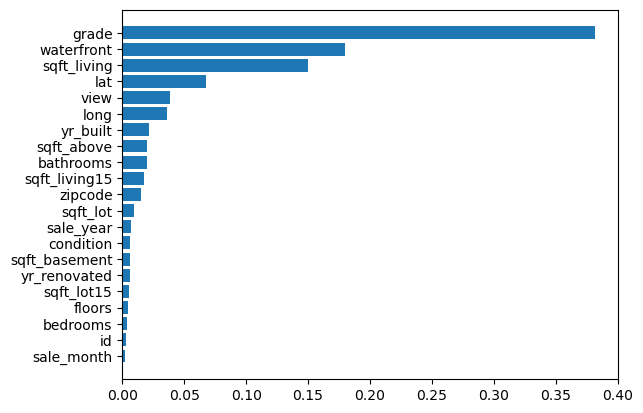

In [862]:
model1 = XGBRegressor()
model1.fit(X_train, y_train)

y_pred_1 = model1.predict(X_test)
y_pred_train_1 = model1.predict(X_train)

sort_idx = model1.feature_importances_.argsort()
plt.barh(X_test.columns[sort_idx],model1.feature_importances_[sort_idx])
plt.show()



In [863]:
new_row = evaluate_model("XGB 0", y_train, y_pred_train_1, y_test, y_pred_1)
metrics_df = pd.concat([metrics_df, new_row], ignore_index=True)
metrics_df 

,Model,Train_RMSE,Test_RMSE,Train_MAE,Test_MAE,Train_R2,Test_R2
0,Linear Regression,197659.54,211427.88,124881.99,126734.61,0.70,0.70
1,XGB 0,53442.07,138137.45,38170.54,68372.68,0.98,0.87


# XGB regressor with less features

Removing features poorly correlated to house price

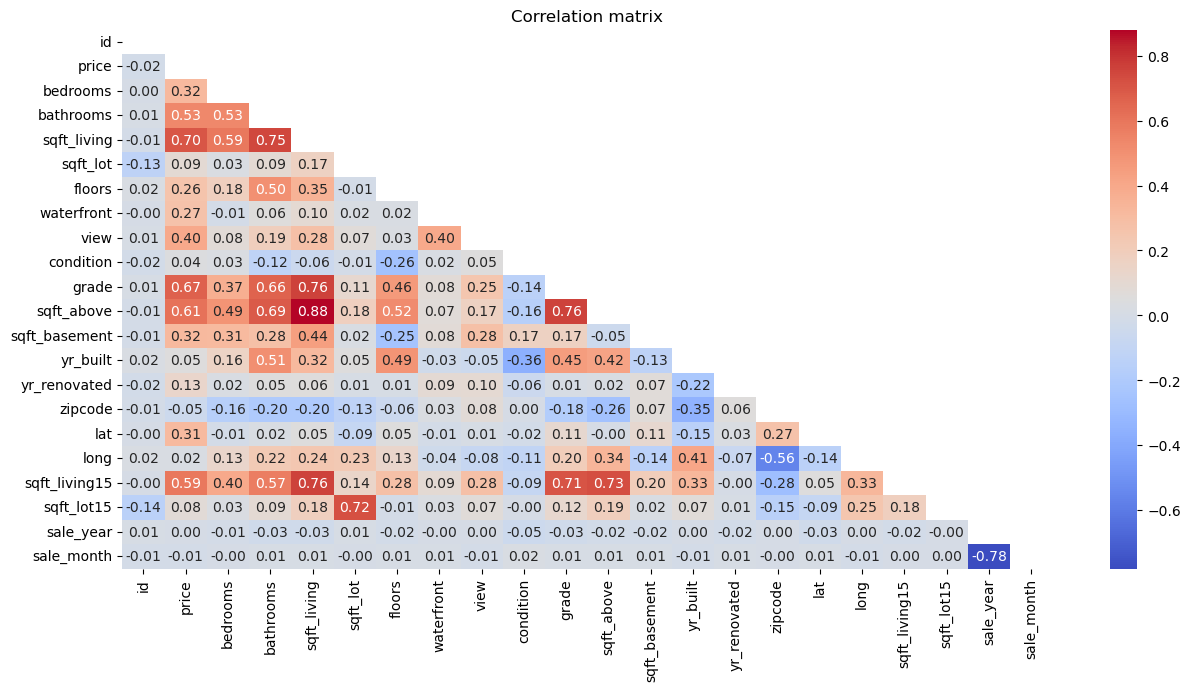

In [864]:
correlation_matrix = round(df[df.columns].corr(),2)

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
plt.figure(figsize=(15, 7))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation matrix")
plt.show()

In [865]:
df2.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,lat,sqft_living15
count,21612.00,21612.00,21612.00,21612.00,21612.00,21612.00,21612.00,21612.00,21612.00,21612.00,21612.00,21612.00,21612.00,21612.00,21612.00,21612.00
mean,540083.52,3.37,2.11,2079.92,15107.39,1.49,0.01,0.23,3.41,7.66,1788.43,291.50,1971.01,84.41,47.56,1986.58
std,367135.06,0.91,0.77,918.46,41421.42,0.54,0.09,0.77,0.65,1.18,828.09,442.58,29.37,401.69,0.14,685.39
min,75000.00,0.00,0.00,290.00,520.00,1.00,0.00,0.00,1.00,1.00,290.00,0.00,1900.00,0.00,47.16,399.00
25%,321837.50,3.00,1.75,1426.50,5040.00,1.00,0.00,0.00,3.00,7.00,1190.00,0.00,1951.00,0.00,47.47,1490.00
50%,450000.00,3.00,2.25,1910.00,7619.00,1.50,0.00,0.00,3.00,7.00,1560.00,0.00,1975.00,0.00,47.57,1840.00
75%,645000.00,4.00,2.50,2550.00,10688.25,2.00,0.00,0.00,4.00,8.00,2210.00,560.00,1997.00,0.00,47.68,2360.00
max,7700000.00,11.00,8.00,13540.00,1651359.00,3.50,1.00,4.00,5.00,13.00,9410.00,4820.00,2015.00,2015.00,47.78,6210.00


In [866]:
df2 = df.drop(['id', 'sale_month','sale_year','sqft_lot15','long','zipcode'], axis = 1)

X_train shape: (17289, 15)
X_test shape: (4323, 15)


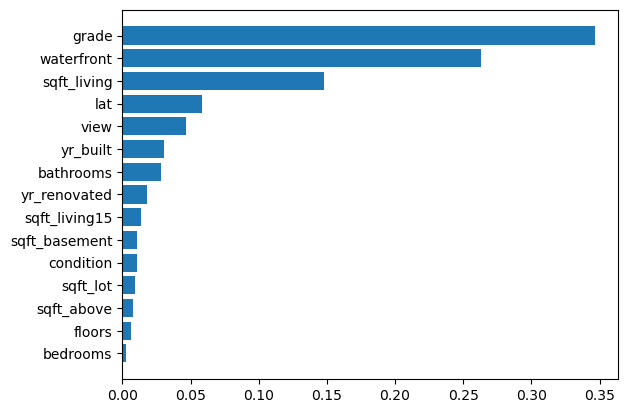

In [867]:
X2 = df2.drop('price', axis =1)
y2 = df2['price']
X_train, X_test, y_train, y_test = train_test_split(
    X2, y2, test_size=0.2, random_state=RANDOM_STATE
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

model1 = XGBRegressor()
model1.fit(X_train, y_train)

y_pred = model1.predict(X_test)
y_pred_train = model1.predict(X_train)

new_row = evaluate_model("Model after feature reduction", y_train, y_pred_train, y_test, y_pred)
metrics_df = pd.concat([metrics_df, new_row], ignore_index=True)

model1.feature_importances_
sort_idx = model1.feature_importances_.argsort()
plt.barh(X_test.columns[sort_idx],model1.feature_importances_[sort_idx])
plt.show()


In [868]:
metrics_df

,Model,Train_RMSE,Test_RMSE,Train_MAE,Test_MAE,Train_R2,Test_R2
0,Linear Regression,197659.54,211427.88,124881.99,126734.61,0.70,0.70
1,XGB 0,53442.07,138137.45,38170.54,68372.68,0.98,0.87
2,Model after feature reduction,69917.72,170449.96,48882.00,83006.90,0.96,0.81


# XGB with log normalization

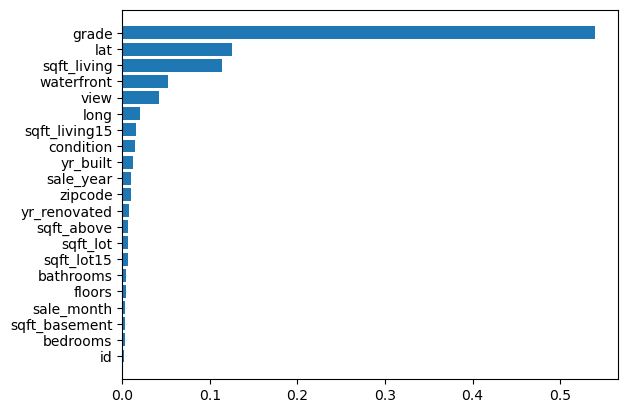

In [869]:
X_train_log, X_test_log, y_train, y_test = X_train_0.copy(), X_test_0.copy(), y_train_0.copy(), y_test_0.copy()

y_train_log = np.log1p(y_train)
#y_test_log= np.log1p(y_test)

model_log = XGBRegressor()
model_log.fit(X_train_log, y_train_log)

y_pred_log = model_log.predict(X_test_log)
y_pred_train_log = np.expm1(model_log.predict(X_train_log))

sort_idx = model_log.feature_importances_.argsort()
plt.barh(X_test_log.columns[sort_idx],model_log.feature_importances_[sort_idx])
plt.show()

In [870]:
new_row = evaluate_model("Model after log", y_train, y_pred_train_log, y_test, y_pred)
metrics_df = pd.concat([metrics_df, new_row], ignore_index=True)

In [871]:
metrics_df

,Model,Train_RMSE,Test_RMSE,Train_MAE,Test_MAE,Train_R2,Test_R2
0,Linear Regression,197659.54,211427.88,124881.99,126734.61,0.70,0.70
1,XGB 0,53442.07,138137.45,38170.54,68372.68,0.98,0.87
2,Model after feature reduction,69917.72,170449.96,48882.00,83006.90,0.96,0.81
3,Model after log,60842.61,170449.96,39406.15,83006.90,0.97,0.81


# XGB with Hyperparameters tuning

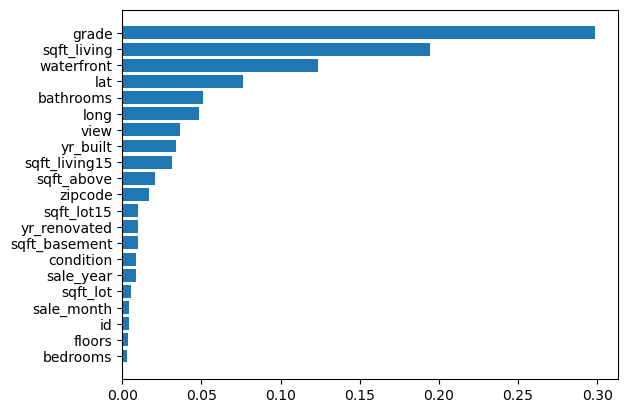

,Model,Train_RMSE,Test_RMSE,Train_MAE,Test_MAE,Train_R2,Test_R2
0,Linear Regression,197659.54,211427.88,124881.99,126734.61,0.70,0.70
1,XGB 0,53442.07,138137.45,38170.54,68372.68,0.98,0.87
2,Model after feature reduction,69917.72,170449.96,48882.00,83006.90,0.96,0.81
3,Model after log,60842.61,170449.96,39406.15,83006.90,0.97,0.81
4,Model with Hyperparameter tuning,87683.65,137527.07,57719.48,70875.04,0.94,0.87


In [872]:
X_train, X_test, y_train, y_test = X_train_0.copy(), X_test_0.copy(), y_train_0.copy(), y_test_0.copy()

model_H = XGBRegressor(
    objective='reg:squarederror', 
    n_estimators=400, 
    learning_rate=0.05, 
    max_depth=4)

model_H.fit(X_train, y_train)

y_pred = model_H.predict(X_test)
y_pred_train = model_H.predict(X_train)

sort_idx = model_H.feature_importances_.argsort()
plt.barh(X_test.columns[sort_idx],model_H.feature_importances_[sort_idx])
plt.show()

new_row = evaluate_model("Model with Hyperparameter tuning", y_train, y_pred_train, y_test, y_pred)
metrics_df = pd.concat([metrics_df, new_row], ignore_index=True)

metrics_df

# XGBOOST with RandomizedSearchCV

Fitting 5 folds for each of 250 candidates, totalling 1250 fits
Best parameters: {'n_estimators': 700, 'max_depth': 4, 'learning_rate': 0.1, 'gamma': 0.1}


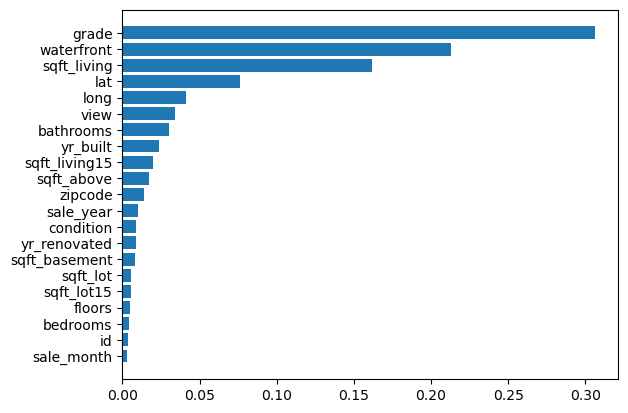

,Model,Train_RMSE,Test_RMSE,Train_MAE,Test_MAE,Train_R2,Test_R2
0,Linear Regression,197659.54,211427.88,124881.99,126734.61,0.70,0.70
1,XGB 0,53442.07,138137.45,38170.54,68372.68,0.98,0.87
2,Model after feature reduction,69917.72,170449.96,48882.00,83006.90,0.96,0.81
3,Model after log,60842.61,170449.96,39406.15,83006.90,0.97,0.81
4,Model with Hyperparameter tuning,87683.65,137527.07,57719.48,70875.04,0.94,0.87
5,Model with HP tuning using Random Search,63663.46,131478.17,44325.88,66407.79,0.97,0.88


In [873]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor
X_train, X_test, y_train, y_test = X_train_0.copy(), X_test_0.copy(), y_train_0.copy(), y_test_0.copy()

xgb = XGBRegressor()

# Define parameter distribution for sampling
param_dist = {
    'n_estimators': [100, 300, 500, 700], #add 1 or 2 < 100
    'max_depth': list(range(3, 10)),
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'gamma': [0, 0.1, 0.3],
}


# Randomized search
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=250,                 # number of random combinations to try, try with 250
    cv=5,                      # cross-validation
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,                 # use all CPU cores
    verbose=2,
    random_state=42
)

# Fit randomized search
#random_search.fit(X_train, y_train)
random_search.fit(
    X_train, y_train,
)
# Best parameters
print("Best parameters:", random_search.best_params_)
best_model = random_search.best_estimator_

best_model.fit(
    X_train, y_train,
)
# Best model

# Evaluate on test set
y_pred = best_model.predict(X_test)
y_pred_train = best_model.predict(X_train)

sort_idx = best_model.feature_importances_.argsort()
plt.barh(X_test.columns[sort_idx],best_model.feature_importances_[sort_idx])
plt.show()

new_row = evaluate_model("Model with HP tuning using Random Search", y_train, y_pred_train, y_test, y_pred)
metrics_df = pd.concat([metrics_df, new_row], ignore_index=True)

metrics_df

In [874]:
mae = mean_absolute_error(y_test, y_pred)
print("Test MAE:", mae)

Test MAE: 66407.79065102359


# XGB with L1 regularization

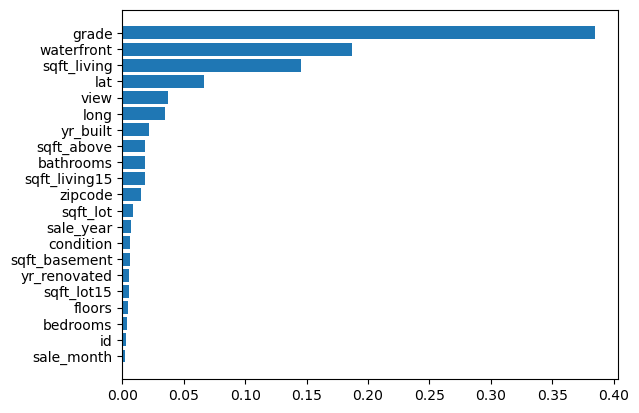

,Model,Train_RMSE,Test_RMSE,Train_MAE,Test_MAE,Train_R2,Test_R2
0,Linear Regression,197659.54,211427.88,124881.99,126734.61,0.70,0.70
1,XGB 0,53442.07,138137.45,38170.54,68372.68,0.98,0.87
2,Model after feature reduction,69917.72,170449.96,48882.00,83006.90,0.96,0.81
3,Model after log,60842.61,170449.96,39406.15,83006.90,0.97,0.81
4,Model with Hyperparameter tuning,87683.65,137527.07,57719.48,70875.04,0.94,0.87
5,Model with HP tuning using Random Search,63663.46,131478.17,44325.88,66407.79,0.97,0.88
6,Model with L1 reg.,52762.73,133569.18,37958.69,67985.89,0.98,0.88


In [875]:
X_train_L1, X_test_L1, y_train_L1, y_test_L1 = X_train_0.copy(), X_test_0.copy(), y_train_0.copy(), y_test_0.copy()
alpha = 200
model_L1 = XGBRegressor(reg_alpha=alpha)
model_L1.fit(X_train_L1, y_train_L1)

y_pred_L1 = model_L1.predict(X_test_L1)
y_pred_train_L1 = model_L1.predict(X_train_L1)

sort_idx = model_L1.feature_importances_.argsort()
plt.barh(X_test_L1.columns[sort_idx],model_L1.feature_importances_[sort_idx])
plt.show()

new_row = evaluate_model(f"Model with L1 reg.", y_train_L1, y_pred_train_L1, y_test_L1, y_pred_L1)
metrics_df = pd.concat([metrics_df, new_row], ignore_index=True)

metrics_df

# XGB with L2 Regularization

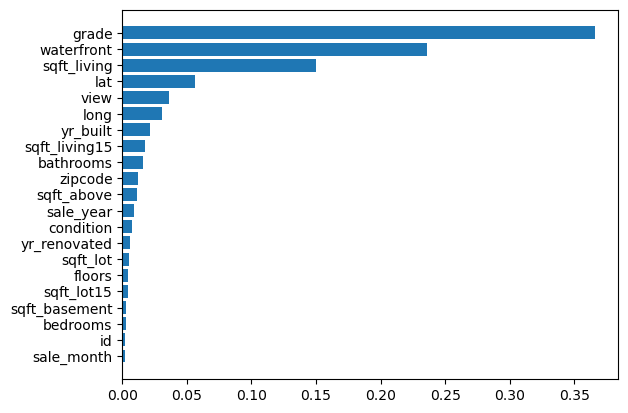

,Model,Train_RMSE,Test_RMSE,Train_MAE,Test_MAE,Train_R2,Test_R2
0,Linear Regression,197659.54,211427.88,124881.99,126734.61,0.70,0.70
1,XGB 0,53442.07,138137.45,38170.54,68372.68,0.98,0.87
2,Model after feature reduction,69917.72,170449.96,48882.00,83006.90,0.96,0.81
3,Model after log,60842.61,170449.96,39406.15,83006.90,0.97,0.81
4,Model with Hyperparameter tuning,87683.65,137527.07,57719.48,70875.04,0.94,0.87
5,Model with HP tuning using Random Search,63663.46,131478.17,44325.88,66407.79,0.97,0.88
6,Model with L1 reg.,52762.73,133569.18,37958.69,67985.89,0.98,0.88
7,Model with L2 and L1 reg.,60533.45,130475.76,42367.74,68419.77,0.97,0.89


In [876]:
X_train_L2, X_test_L2, y_train_L2, y_test_L2 = X_train_0.copy(), X_test_0.copy(), y_train_0.copy(), y_test_0.copy()
lambda_l2 = 5
model_L2 = XGBRegressor(reg_lambda=lambda_l2, reg_alpha = alpha)
model_L2.fit(X_train_L2, y_train_L2)

y_pred_L2 = model_L2.predict(X_test_L2)
y_pred_train_L2 = model_L2.predict(X_train_L2)

sort_idx = model_L2.feature_importances_.argsort()
plt.barh(X_test_L2.columns[sort_idx],model_L2.feature_importances_[sort_idx])
plt.show()

new_row = evaluate_model("Model with L2 and L1 reg. ", y_train_L2, y_pred_train_L2, y_test_L2, y_pred_L2)
metrics_df = pd.concat([metrics_df, new_row], ignore_index=True)

metrics_df

# RESCALING

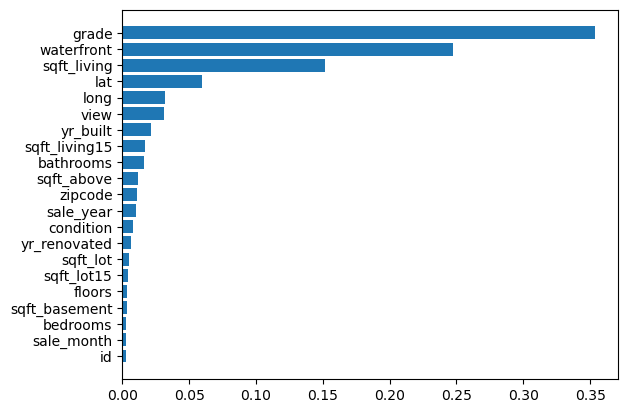

,Model,Train_RMSE,Test_RMSE,Train_MAE,Test_MAE,Train_R2,Test_R2
0,Linear Regression,197659.54,211427.88,124881.99,126734.61,0.70,0.70
1,XGB 0,53442.07,138137.45,38170.54,68372.68,0.98,0.87
2,Model after feature reduction,69917.72,170449.96,48882.00,83006.90,0.96,0.81
3,Model after log,60842.61,170449.96,39406.15,83006.90,0.97,0.81
4,Model with Hyperparameter tuning,87683.65,137527.07,57719.48,70875.04,0.94,0.87
5,Model with HP tuning using Random Search,63663.46,131478.17,44325.88,66407.79,0.97,0.88
6,Model with L1 reg.,52762.73,133569.18,37958.69,67985.89,0.98,0.88
7,Model with L2 and L1 reg.,60533.45,130475.76,42367.74,68419.77,0.97,0.89
8,Model L2 standardized,60142.53,131252.99,42124.80,68663.38,0.97,0.89


In [877]:
X_train, X_test, y_train, y_test = X_train_0.copy(), X_test_0.copy(), y_train_0.copy(), y_test_0.copy()

normalizer = StandardScaler()
normalizer = normalizer.fit(X_train)
X_train_normalized = normalizer.transform(X_train)
X_train_normalized = pd.DataFrame(X_train_normalized,columns=X_train.columns)
X_test_normalized = normalizer.transform(X_test)
X_test_normalized = pd.DataFrame(X_test_normalized,columns=X_test.columns)

lambda_l2 = 5
model_L2 = XGBRegressor(reg_lambda=lambda_l2, reg_alpha = alpha)
model_L2.fit(X_train_normalized, y_train)

y_pred_L2 = model_L2.predict(X_test_normalized)
y_pred_train_L2 = model_L2.predict(X_train_normalized)

sort_idx = model_L2.feature_importances_.argsort()
plt.barh(X_test_normalized.columns[sort_idx],model_L2.feature_importances_[sort_idx])
plt.show()

new_row = evaluate_model("Model L2 standardized", y_train_L2, y_pred_train_L2, y_test_L2, y_pred_L2)
metrics_df = pd.concat([metrics_df, new_row], ignore_index=True)

metrics_df

# Save model

In [878]:
model_L2.save_model("../data/xgb_model_L2.json")

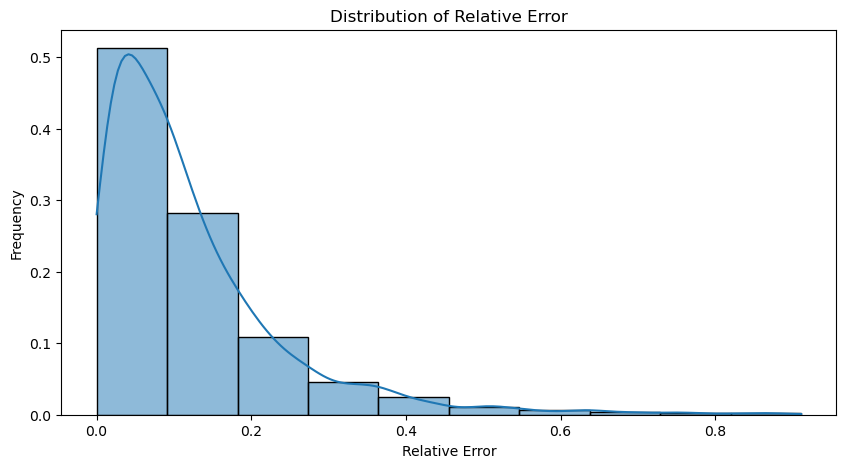

In [879]:
checks = X_test_L2.copy()
checks["y_pred"] = y_pred_L2
checks['y_real'] = y_test_L2
checks['delta'] = y_test_L2 - y_pred_L2
checks['relative_error'] = abs(checks.delta / checks.y_real)

plt.figure(figsize=(10, 5))
sns.histplot(checks[checks['relative_error']<= 1.0]['relative_error'], bins=10, kde=True, stat = "probability")
plt.title("Distribution of Relative Error")
plt.xlabel("Relative Error")
plt.ylabel("Frequency")
plt.show()



In [880]:
checks.grade.value_counts()

grade
7     1803
8     1173
9      526
6      422
10     223
11      97
5       58
12      17
13       3
4        1
Name: count, dtype: int64

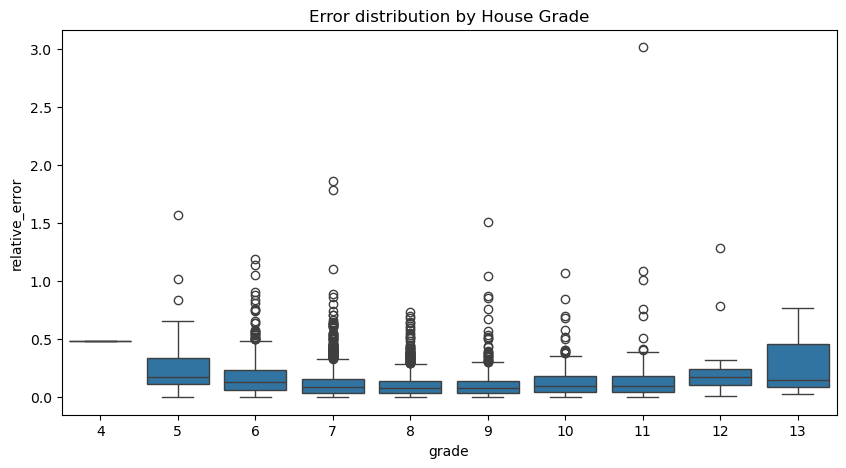

In [881]:
plt.figure(figsize=(10, 5))

sns.boxplot(data=checks, x="grade", y="relative_error")

plt.title("Error distribution by House Grade")
plt.show()

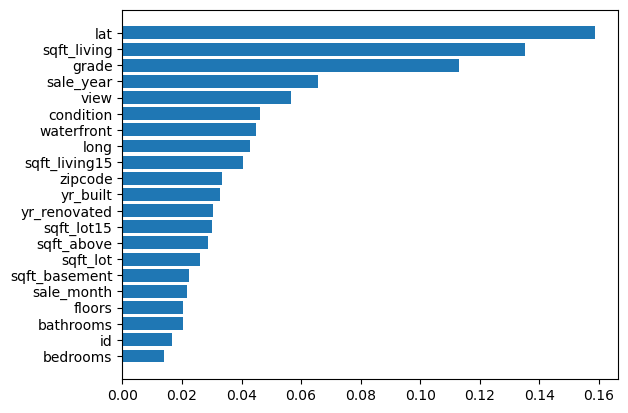

,Model,Train_RMSE,Test_RMSE,Train_MAE,Test_MAE,Train_R2,Test_R2
0,Linear Regression,197659.54,211427.88,124881.99,126734.61,0.70,0.70
1,XGB 0,53442.07,138137.45,38170.54,68372.68,0.98,0.87
2,Model after feature reduction,69917.72,170449.96,48882.00,83006.90,0.96,0.81
3,Model after log,60842.61,170449.96,39406.15,83006.90,0.97,0.81
4,Model with Hyperparameter tuning,87683.65,137527.07,57719.48,70875.04,0.94,0.87
5,Model with HP tuning using Random Search,63663.46,131478.17,44325.88,66407.79,0.97,0.88
6,Model with L1 reg.,52762.73,133569.18,37958.69,67985.89,0.98,0.88
7,Model with L2 and L1 reg.,60533.45,130475.76,42367.74,68419.77,0.97,0.89
8,Model L2 standardized,60142.53,131252.99,42124.80,68663.38,0.97,0.89
9,Model after obj reg.,89609.79,137058.32,46668.43,69683.14,0.94,0.87


In [882]:
X_train_obj, X_test_obj, y_train_obj, y_test_obj = X_train_0.copy(), X_test_0.copy(), y_train_0.copy(), y_test_0.copy()
model_obj = XGBRegressor(objective='reg:absoluteerror', eval_metric='rmse')
model_obj.fit(X_train_obj, y_train_obj)

y_pred_obj = model_obj.predict(X_test_obj)
y_pred_train_obj = model_obj.predict(X_train_obj)

sort_idx = model_obj.feature_importances_.argsort()
plt.barh(X_test_obj.columns[sort_idx],model_obj.feature_importances_[sort_idx])
plt.show()

new_row = evaluate_model("Model after obj reg.", y_train_obj, y_pred_train_obj, y_test_obj, y_pred_obj)
metrics_df = pd.concat([metrics_df, new_row], ignore_index=True)

metrics_df

# TRY REMOVE OUTLIERS

In [883]:
def identify_outliers_iqr(df, column, threshold=1.5):
    Q1 = df[column].quantile(0.05)
    Q3 = df[column].quantile(0.95)
    IQR = Q3 - Q1
    lower_bound = Q1 - threshold * IQR
    if lower_bound < df2[column].min():
        lower_bound = df2[column].min()
    upper_bound = Q3 + threshold * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

for column in df2.columns:
    column_out, column_lower, column_upper = identify_outliers_iqr(df2, column)
    print(f'{column}: {len(column_out)}\nbounds: {column_lower:.2f} to {column_upper:.2f}\nminmax: {df2[column].min()} to {df2[column].max()}\n')

price: 84
bounds: 75000.00 to 2576350.00
minmax: 75000.0 to 7700000.0

bedrooms: 4
bounds: 0.00 to 9.50
minmax: 0 to 11

bathrooms: 4
bounds: 0.00 to 7.25
minmax: 0.0 to 8.0

sqft_living: 10
bounds: 290.00 to 7990.00
minmax: 290 to 13540

sqft_lot: 438
bounds: 520.00 to 105650.25
minmax: 520 to 1651359

floors: 0
bounds: 1.00 to 3.50
minmax: 1.0 to 3.5

waterfront: 163
bounds: 0.00 to 0.00
minmax: 0 to 1

view: 0
bounds: 0.00 to 5.00
minmax: 0 to 4

condition: 0
bounds: 1.00 to 8.00
minmax: 1 to 5

grade: 0
bounds: 1.00 to 16.00
minmax: 1 to 13

sqft_above: 9
bounds: 290.00 to 7225.00
minmax: 290 to 9410

sqft_basement: 6
bounds: 0.00 to 2975.00
minmax: 0 to 4820

yr_built: 0
bounds: 1900.00 to 2155.00
minmax: 1900 to 2015

yr_renovated: 914
bounds: 0.00 to 0.00
minmax: 0 to 2015

lat: 0
bounds: 47.16 to 48.41
minmax: 47.1559 to 47.7776

sqft_living15: 0
bounds: 399.00 to 6540.00
minmax: 399 to 6210



In [884]:
price_out, price_lower, price_upper = identify_outliers_iqr(df, 'price')
print(f'price: {len(price_out)}\nbounds: {price_lower:.2f} to {price_upper:.2f}\nminmax: {df['price'].min()} to {df2['price'].max()}\n')

price: 84
bounds: 75000.00 to 2576350.00
minmax: 75000.0 to 7700000.0



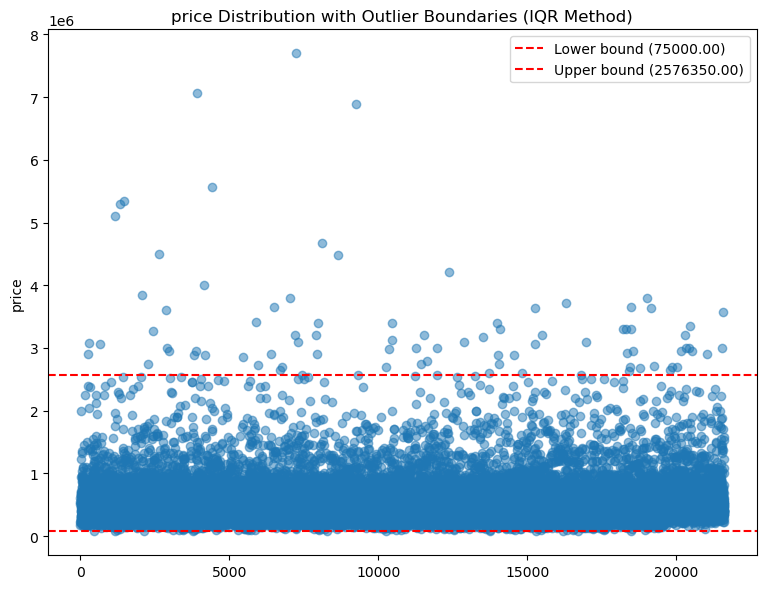

In [885]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.scatter(df.index, df['price'], alpha=0.5)
plt.axhline(y=price_lower, color='r', linestyle='--', label=f'Lower bound ({price_lower:.2f})')
plt.axhline(y=price_upper, color='r', linestyle='--', label=f'Upper bound ({price_upper:.2f})')
plt.title('price Distribution with Outlier Boundaries (IQR Method)')
plt.ylabel('price')
plt.legend()



plt.tight_layout()
plt.show()

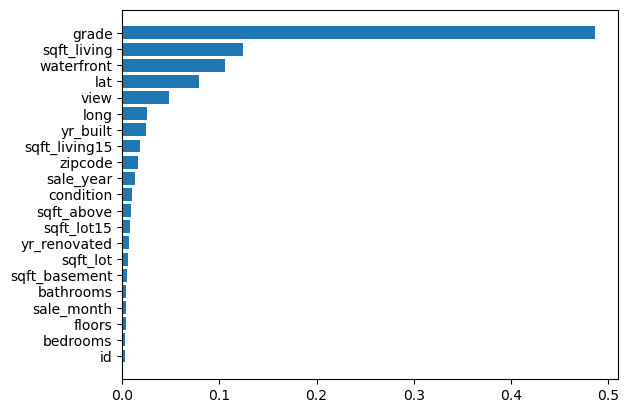

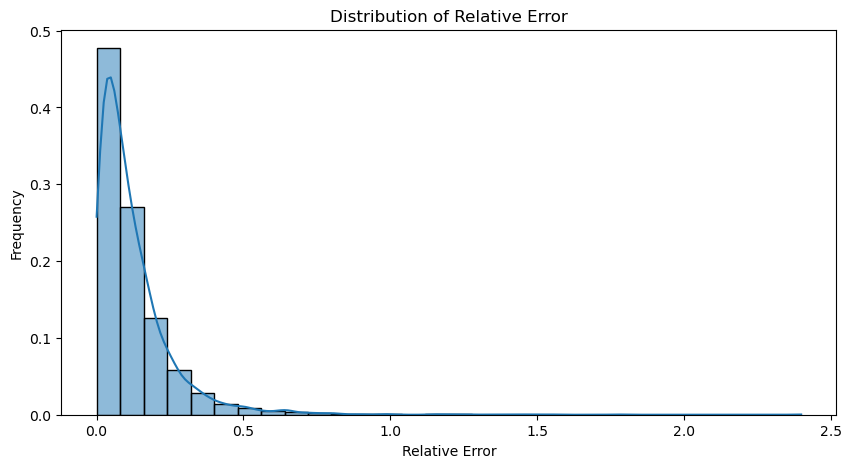

In [895]:
X_train, X_test, y_train, y_test = X_train_0.copy(), X_test_0.copy(), y_train_0.copy(), y_test_0.copy()
ids_out = price_out.id

X_train_w_out = X_train[~X_train['id'].isin(ids_out)]
X_test_w_out = X_test[~X_test['id'].isin(ids_out)]

y_train_w_out = y_train[y_train < price_upper]
y_test_w_out = y_test[y_test < price_upper]


model_w_out = XGBRegressor(reg_lambda=lambda_l2, reg_alpha = alpha)
model_w_out.fit(X_train_w_out, y_train_w_out)

y_pred_w_out = model_w_out.predict(X_test_w_out)
y_pred_train_w_out = model_w_out.predict(X_train_w_out)

sort_idx = model_w_out.feature_importances_.argsort()
plt.barh(X_test_w_out.columns[sort_idx],model_w_out.feature_importances_[sort_idx])
plt.show()

new_row = evaluate_model("Model with L2 and L1 reg. w outliers ", y_train_w_out, y_pred_train_w_out, y_test_w_out, y_pred_w_out)
metrics_df = pd.concat([metrics_df, new_row], ignore_index=True)

metrics_df

checks = X_test_w_out.copy()
checks["y_pred"] = y_pred_w_out
checks['y_real'] = y_test_w_out
checks['delta'] = y_test_w_out - y_pred_w_out
checks['relative_error'] = abs(checks.delta / checks.y_real)

plt.figure(figsize=(10, 5))
sns.histplot(checks['relative_error'], bins=30, kde=True, stat = "probability")
plt.title("Distribution of Relative Error")
plt.xlabel("Relative Error")
plt.ylabel("Frequency")

plt.show()



In [896]:
subset_pct =  checks['relative_error'] * 100
bins = [0, 5, 10, 19, 30, 49, np.inf]

labels = ["0-5%", "6-10%", "10-19%", "20-30%", "30-49%", ">50%"]

binned = pd.cut(subset_pct, bins=bins, labels=labels, include_lowest=True)
table = binned.value_counts().sort_index().to_frame(name="count")
table["relative_freq"] = table["count"] / table["count"].sum()
table["cum_freq"] = table["relative_freq"].cumsum()

table

,count,relative_freq,cum_freq
relative_error,,,
0-5%,1387,0.32,0.32
6-10%,1028,0.24,0.56
10-19%,1078,0.25,0.81
20-30%,476,0.11,0.92
30-49%,231,0.05,0.98
>50%,99,0.02,1.00


In [888]:
metrics_df

,Model,Train_RMSE,Test_RMSE,Train_MAE,Test_MAE,Train_R2,Test_R2
0,Linear Regression,197659.54,211427.88,124881.99,126734.61,0.70,0.70
1,XGB 0,53442.07,138137.45,38170.54,68372.68,0.98,0.87
2,Model after feature reduction,69917.72,170449.96,48882.00,83006.90,0.96,0.81
3,Model after log,60842.61,170449.96,39406.15,83006.90,0.97,0.81
4,Model with Hyperparameter tuning,87683.65,137527.07,57719.48,70875.04,0.94,0.87
5,Model with HP tuning using Random Search,63663.46,131478.17,44325.88,66407.79,0.97,0.88
6,Model with L1 reg.,52762.73,133569.18,37958.69,67985.89,0.98,0.88
7,Model with L2 and L1 reg.,60533.45,130475.76,42367.74,68419.77,0.97,0.89
8,Model L2 standardized,60142.53,131252.99,42124.80,68663.38,0.97,0.89
9,Model after obj reg.,89609.79,137058.32,46668.43,69683.14,0.94,0.87


Fitting 5 folds for each of 250 candidates, totalling 1250 fits
Best parameters: {'n_estimators': 700, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 0}


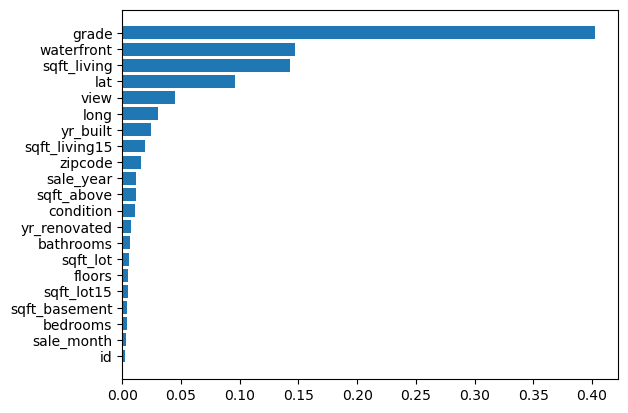

,Model,Train_RMSE,Test_RMSE,Train_MAE,Test_MAE,Train_R2,Test_R2
0,Linear Regression,197659.54,211427.88,124881.99,126734.61,0.70,0.70
1,XGB 0,53442.07,138137.45,38170.54,68372.68,0.98,0.87
2,Model after feature reduction,69917.72,170449.96,48882.00,83006.90,0.96,0.81
3,Model after log,60842.61,170449.96,39406.15,83006.90,0.97,0.81
4,Model with Hyperparameter tuning,87683.65,137527.07,57719.48,70875.04,0.94,0.87
5,Model with HP tuning using Random Search,63663.46,131478.17,44325.88,66407.79,0.97,0.88
6,Model with L1 reg.,52762.73,133569.18,37958.69,67985.89,0.98,0.88
7,Model with L2 and L1 reg.,60533.45,130475.76,42367.74,68419.77,0.97,0.89
8,Model L2 standardized,60142.53,131252.99,42124.80,68663.38,0.97,0.89
9,Model after obj reg.,89609.79,137058.32,46668.43,69683.14,0.94,0.87


In [ ]:
'''X_train, X_test, y_train, y_test = X_train_w_out.copy(), X_test_w_out.copy(), y_train_w_out.copy(), y_test_w_out.copy()

xgb = XGBRegressor()

# Define parameter distribution for sampling
param_dist = {
    'n_estimators': [100, 300, 500, 700], #add 1 or 2 < 100
    'max_depth': list(range(3, 10)),
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'gamma': [0, 0.1, 0.3],
}


# Randomized search
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=250,                 # number of random combinations to try, try with 250
    cv=5,                      # cross-validation
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,                 # use all CPU cores
    verbose=2,
    random_state=42
)

# Fit randomized search
#random_search.fit(X_train, y_train)
random_search.fit(
    X_train, y_train,
)'''


Best parameters: {'n_estimators': 700, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 0}


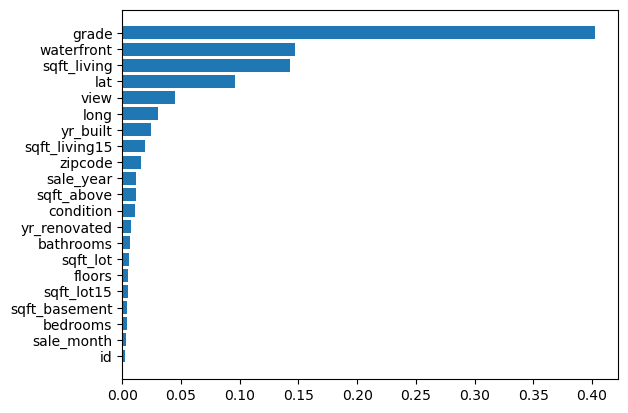

,Model,Train_RMSE,Test_RMSE,Train_MAE,Test_MAE,Train_R2,Test_R2
0,Linear Regression,197659.54,211427.88,124881.99,126734.61,0.70,0.70
1,XGB 0,53442.07,138137.45,38170.54,68372.68,0.98,0.87
2,Model after feature reduction,69917.72,170449.96,48882.00,83006.90,0.96,0.81
3,Model after log,60842.61,170449.96,39406.15,83006.90,0.97,0.81
4,Model with Hyperparameter tuning,87683.65,137527.07,57719.48,70875.04,0.94,0.87
5,Model with HP tuning using Random Search,63663.46,131478.17,44325.88,66407.79,0.97,0.88
6,Model with L1 reg.,52762.73,133569.18,37958.69,67985.89,0.98,0.88
7,Model with L2 and L1 reg.,60533.45,130475.76,42367.74,68419.77,0.97,0.89
8,Model L2 standardized,60142.53,131252.99,42124.80,68663.38,0.97,0.89
9,Model after obj reg.,89609.79,137058.32,46668.43,69683.14,0.94,0.87


In [900]:
X_train, X_test, y_train, y_test = X_train_w_out.copy(), X_test_w_out.copy(), y_train_w_out.copy(), y_test_w_out.copy()
# Best parameters
print("Best parameters:", random_search.best_params_)
best_model = random_search.best_estimator_

best_model.fit(
    X_train, y_train,
)
# Best model

# Evaluate on test set
y_pred = best_model.predict(X_test)
y_pred_train = best_model.predict(X_train)

sort_idx = best_model.feature_importances_.argsort()
plt.barh(X_test.columns[sort_idx],best_model.feature_importances_[sort_idx])
plt.show()

new_row = evaluate_model("Model w HP Rand Search tuning - outliers", y_train, y_pred_train, y_test, y_pred)
metrics_df = pd.concat([metrics_df, new_row], ignore_index=True)

metrics_df

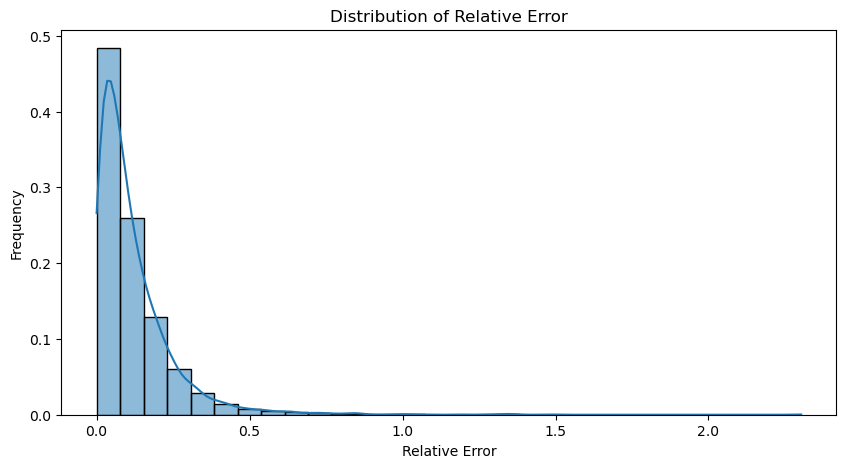

,count,relative_freq,cum_freq
relative_error,,,
0-5%,1451,0.34,0.34
6-10%,1058,0.25,0.58
10-19%,995,0.23,0.82
20-30%,480,0.11,0.93
30-49%,228,0.05,0.98
>50%,87,0.02,1.00


In [901]:
checks = X_test.copy()
checks["y_pred"] = y_pred
checks['y_real'] = y_test
checks['delta'] = y_test - y_pred
checks['relative_error'] = abs(checks.delta / checks.y_real)

plt.figure(figsize=(10, 5))
sns.histplot(checks['relative_error'], bins=30, kde=True, stat = "probability")
plt.title("Distribution of Relative Error")
plt.xlabel("Relative Error")
plt.ylabel("Frequency")

plt.show()

subset_pct =  checks['relative_error'] * 100
bins = [0, 5, 10, 19, 30, 49, np.inf]

labels = ["0-5%", "6-10%", "10-19%", "20-30%", "30-49%", ">50%"]

binned = pd.cut(subset_pct, bins=bins, labels=labels, include_lowest=True)
table = binned.value_counts().sort_index().to_frame(name="count")
table["relative_freq"] = table["count"] / table["count"].sum()
table["cum_freq"] = table["relative_freq"].cumsum()

table

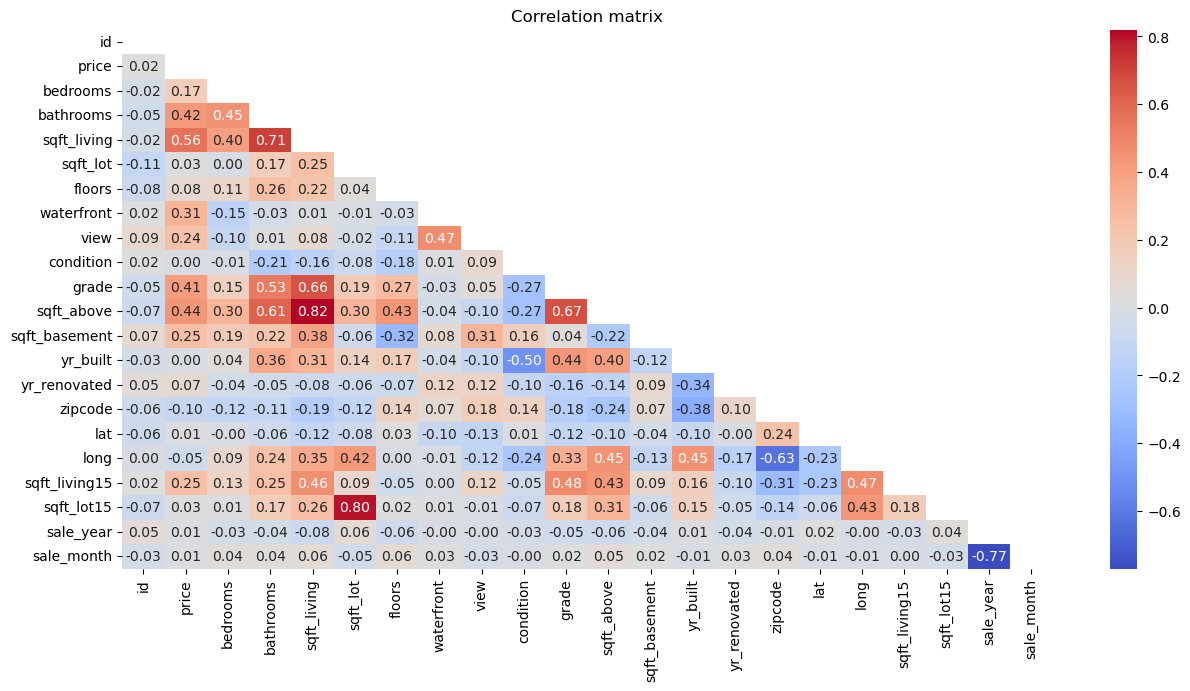

In [21]:
correlation_matrix = round(df[df['price']>1000000][df.columns].corr(),2)

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
plt.figure(figsize=(15, 7))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation matrix")
plt.show()

C:\Users\ranik\AppData\Local\Temp\ipykernel_30980\3764065181.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


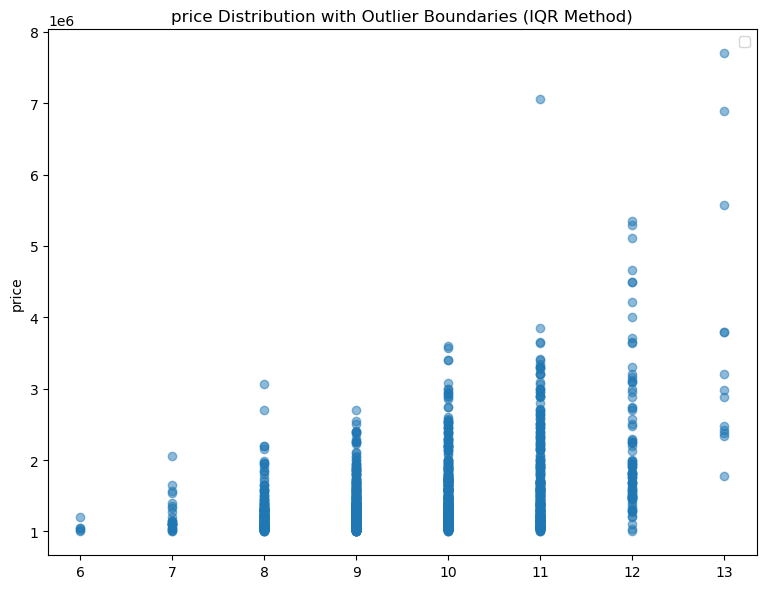

In [25]:
million = df[df['price']>1000000]
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.scatter(y = million['price'], x = million['grade'], alpha=0.5)
#plt.axhline(y=price_lower, color='r', linestyle='--', label=f'Lower bound ({price_lower:.2f})')
#plt.axhline(y=price_upper, color='r', linestyle='--', label=f'Upper bound ({price_upper:.2f})')
plt.title('price Distribution with Outlier Boundaries (IQR Method)')
plt.ylabel('price')
plt.legend()



plt.tight_layout()
plt.show()